In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
df = pd.read_csv('../data/raw/superstore_sales.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🎯 Business Questions We're Exploring
1. Which product categories generate the most sales and profit?
2. Are there regions or segments that consistently underperform?
3. Does discounting actually hurt profitability?
4. Are there seasonal trends in sales?
5. Which sub-categories have unusually high or low profit margins?

In [3]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n")
df.info()

Shape (rows, columns): (9994, 21)

Column names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   objec

In [4]:
#Checking Missing Values
print("Missing values per column:\n")
print(df.isnull().sum())

#Checking Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values per column:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Number of duplicate rows: 0


## 🧹 Data Quality Check
- Dataset has **9,994 rows** and **21 columns**
- **No missing values** found in any column
- **No duplicate rows** found
- Data types are appropriate, except `Order Date` and `Ship Date` which need conversion to datetime format for time-based analysis

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Verify conversion
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [6]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


## 📈 Key Observations from Summary Statistics
- Sales range widely (₹0.44 to ₹22,638) — suggests potential outliers
- Profit has a **minimum of -₹6,599**, meaning some orders resulted in significant losses
- Discounts range from 0% to 80% — worth investigating if high discounts correlate with losses

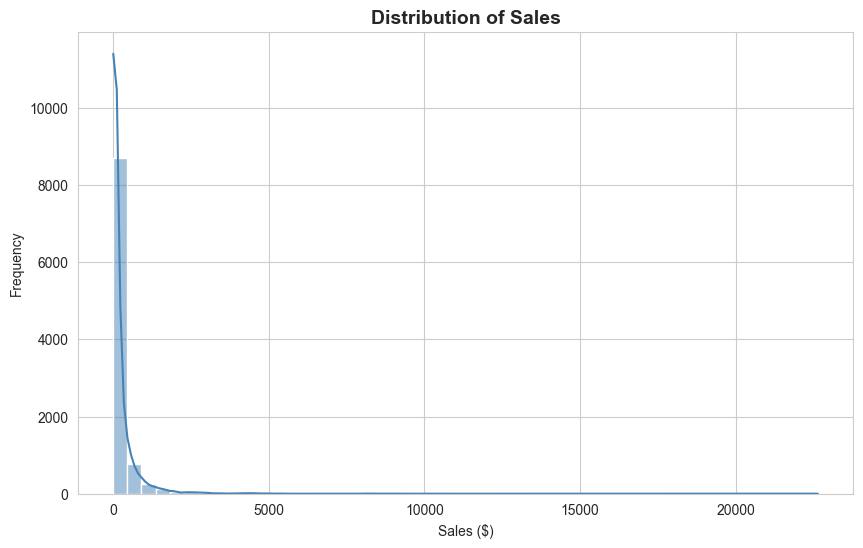

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.show()

## 📊 Univariate Analysis: Sales Distribution
The Sales distribution is heavily **right-skewed** — most transactions are small (under $1,000), 
with a long tail of high-value orders extending up to $22,000+. This suggests the presence of 
a few large "whale" orders alongside many typical smaller purchases.

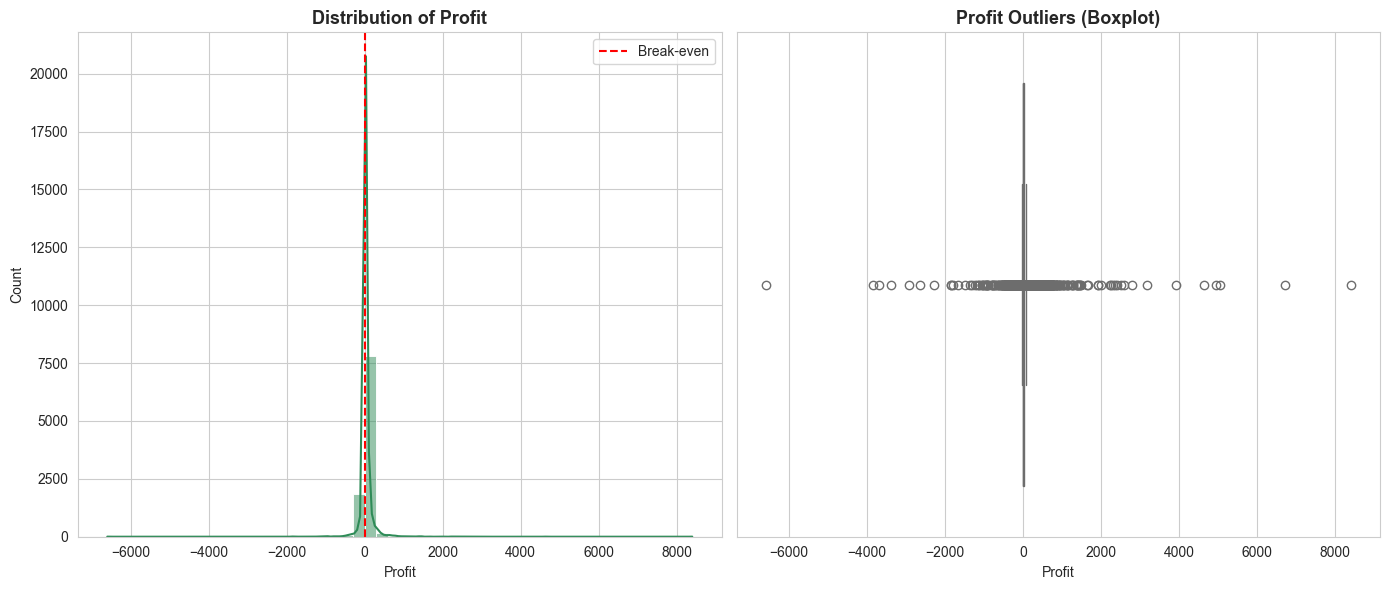

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.histplot(df['Profit'], bins=50, kde=True, color='seagreen', ax=axes[0])
axes[0].set_title('Distribution of Profit', fontsize=13, fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0].legend()

sns.boxplot(x=df['Profit'], color='salmon', ax=axes[1])
axes[1].set_title('Profit Outliers (Boxplot)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 Univariate Analysis: Profit Distribution
Most orders cluster tightly around the break-even point (profit ≈ $0), but the boxplot reveals 
**numerous outliers** on both sides — some orders show losses exceeding -$6,000, while others 
generate profits over $4,000. This wide spread suggests certain products, categories, or discount 
levels are driving disproportionate gains or losses — worth investigating in bivariate analysis.

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


C:\Users\Admin\AppData\Local\Temp\ipykernel_10248\821737953.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary['Sales'], palette='Blues_d', ax=axes[0])
C:\Users\Admin\AppData\Local\Temp\ipykernel_10248\821737953.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_summary.index, y=category_summary['Profit'], palette='Greens_d', ax=axes[1])


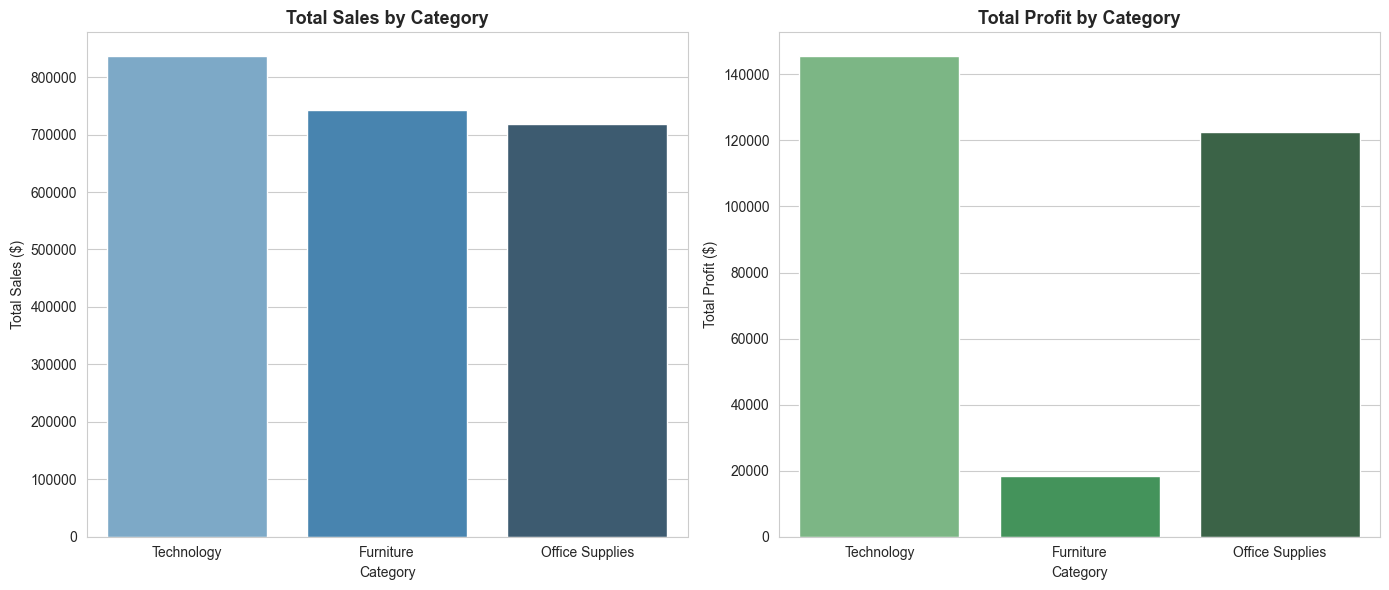

In [9]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(category_summary)

fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.barplot(x=category_summary.index, y=category_summary['Sales'], palette='Blues_d', ax=axes[0])
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')

sns.barplot(x=category_summary.index, y=category_summary['Profit'], palette='Greens_d', ax=axes[1])
axes[1].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.show()

## 💼 Bivariate Analysis: Category Performance
- **Technology** generates the highest profit ($145K) despite not having the highest sales — indicating strong profit margins
- **Furniture** has high sales ($836K) but disproportionately low profit ($18K) — suggesting thin margins or heavy discounting
- **Office Supplies** shows balanced performance across both metrics

This suggests Furniture's pricing/discount strategy may need review.

Correlation coefficient: -0.219
P-value: 0.00000


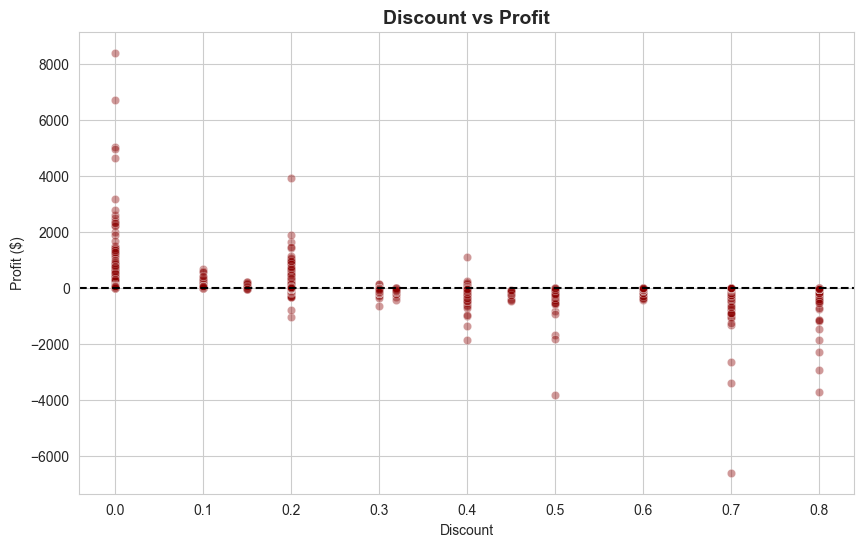

In [10]:
from scipy import stats

# Correlation between Discount and Profit
correlation, p_value = stats.pearsonr(df['Discount'], df['Profit'])
print(f"Correlation coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.5f}")

# Scatter plot to visualize
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Discount'], y=df['Profit'], alpha=0.4, color='darkred')
plt.title('Discount vs Profit', fontsize=14, fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

## 🔬 Hypothesis Test: Does Discount Hurt Profitability?
**Hypothesis:** Higher discounts are associated with lower profit.

**Result:** Pearson correlation = **-0.219**, p-value < 0.00001 (statistically significant)

The scatter plot confirms this — at discounts above 0.5 (50%), the majority of orders show 
**negative profit**. While the correlation is moderate (not extremely strong), it's statistically 
significant and visually clear: **heavy discounting is a major driver of losses** in this dataset.

**Business recommendation:** Review discount policy, especially for discounts above 40-50%.

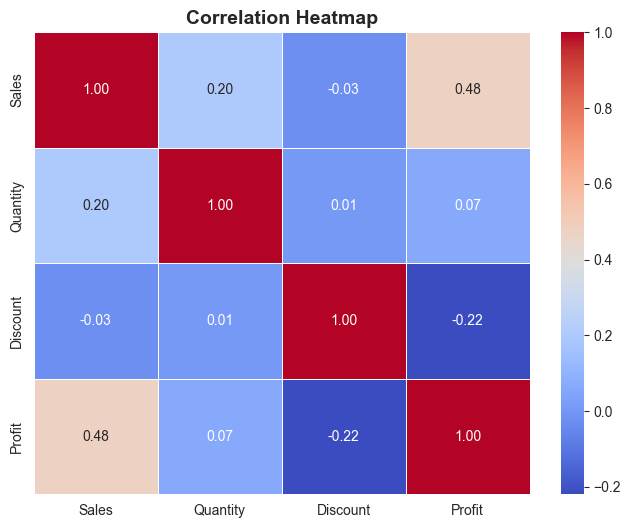

In [11]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

## 🔗 Multivariate Analysis: Correlation Heatmap
- **Sales and Profit** show a moderate positive correlation (0.48) — higher sales generally lead to higher profit
- **Discount and Profit** show a negative correlation (-0.22), confirming our earlier hypothesis test
- **Sales and Discount** have almost no correlation (-0.03) — discounting doesn't meaningfully drive higher sales volume in this dataset
- Quantity has weak correlation with both Sales and Profit, suggesting order value matters more than order size

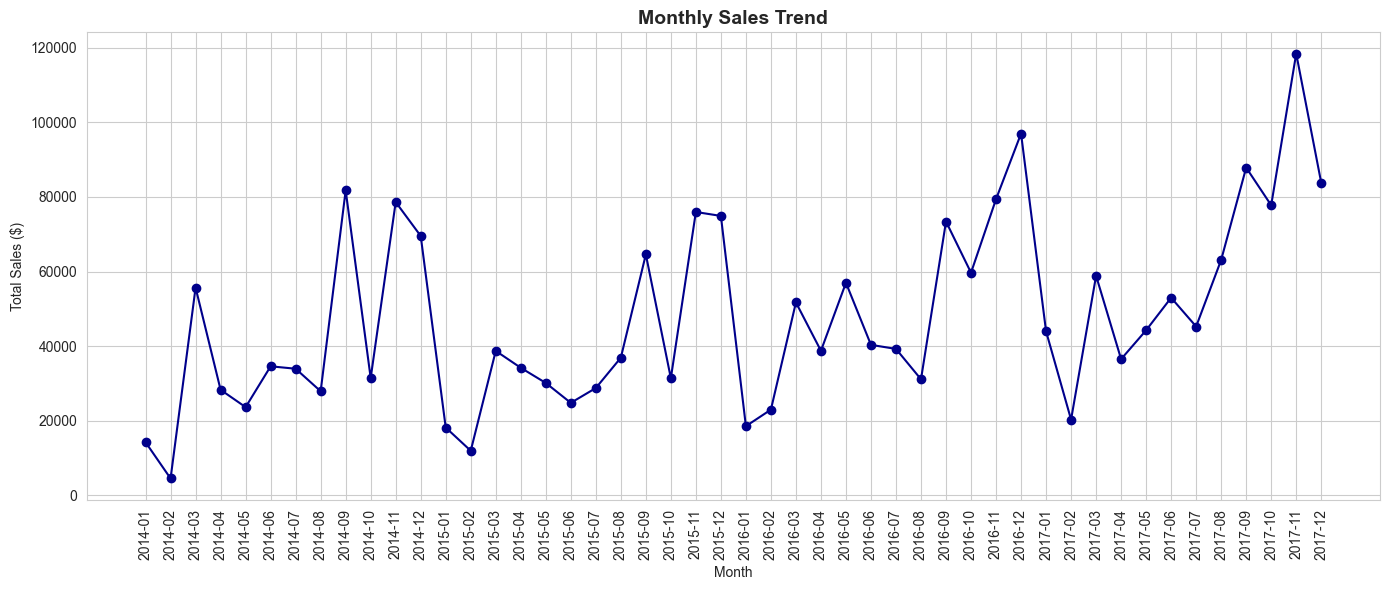

In [12]:
df['Order Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Order Month'], monthly_sales['Sales'], marker='o', color='darkblue')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 📅 Time-Series Analysis: Monthly Sales Trend
- Sales show a **clear upward trend** from 2014 to 2017, indicating overall business growth
- Strong **seasonality** is visible — sales consistently spike every **November-December**, 
  likely driven by holiday shopping season
- Each year starts with relatively lower sales (January-February), a common post-holiday pattern

**Business implication:** Inventory and staffing should be scaled up ahead of Q4 (Oct-Dec) each year.

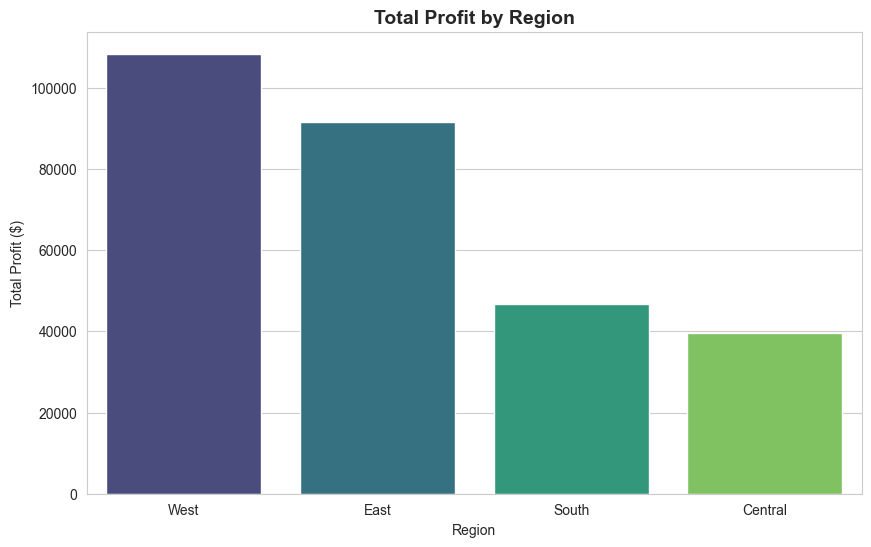

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
South    391721.9050   46749.4303
Central  501239.8908   39706.3625


In [13]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=region_summary.index, y=region_summary['Profit'], hue=region_summary.index, palette='viridis', legend=False)
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.ylabel('Total Profit ($)')
plt.xlabel('Region')
plt.show()

print(region_summary)

## 🌍 Bivariate Analysis: Regional Performance
- **West** region leads in profit ($108K), followed by **East** ($92K)
- **South** ($47K) and **Central** ($40K) significantly underperform despite reasonable sales volumes
- This suggests regional strategy (pricing, logistics, or discount practices) may differ 
  and could be optimized in underperforming regions

# 🎯 Final Insights & Recommendations

## Key Findings
1. **Category Performance:** Technology is the most profitable category ($145K profit) despite 
   moderate sales, while Furniture has high sales ($836K) but very thin profit margins ($18K).
2. **Discounting Hurts Profit:** Statistically significant negative correlation (-0.22, p<0.001) 
   between discount and profit. Discounts above 50% frequently result in losses.
3. **Seasonal Trend:** Sales consistently spike in November-December each year, indicating 
   strong holiday-driven demand.
4. **Regional Gaps:** West and East regions drive most profit; South and Central underperform 
   despite comparable sales volumes.
5. **Data Quality:** Dataset was clean — no missing values or duplicates, requiring minimal 
   preprocessing beyond date formatting.

## Business Recommendations
- 📉 **Cap discounts** at 30-40% for Furniture and Office Supplies, where margins are thinnest
- 📦 **Review Furniture pricing/costs** — high sales aren't translating to profit
- 📅 **Scale inventory and marketing** ahead of Q4 to capture seasonal demand
- 🌍 **Investigate South/Central regions** — possible pricing, logistics, or demand issues

## Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy (for hypothesis testing)

In [14]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Superstore Sales - EDA Profiling Report", explorative=True)
profile.to_file("../reports/superstore_profiling_report.html")

C:\Users\Admin\AppData\Local\Temp\ipykernel_10248\1046238550.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 22/22 [00:00<00:00, 90.90it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
profile.to_notebook_iframe()

In [16]:
import plotly.express as px

category_summary_reset = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index()

fig = px.bar(category_summary_reset, x='Category', y=['Sales', 'Profit'], 
             barmode='group', title='Interactive: Sales vs Profit by Category',
             labels={'value': 'Amount ($)', 'variable': 'Metric'},
             color_discrete_sequence=['steelblue', 'seagreen'])
fig.update_layout(title_font_size=16, title_font_family='Arial Black')
fig.show()

## 🎛️ Interactive Visualization
An interactive Plotly chart was created to let viewers hover over bars for exact values and 
toggle metrics on/off. This makes the Furniture category's profit gap even more visually apparent 
compared to the static chart — the green (profit) bar is nearly invisible next to its blue (sales) bar.

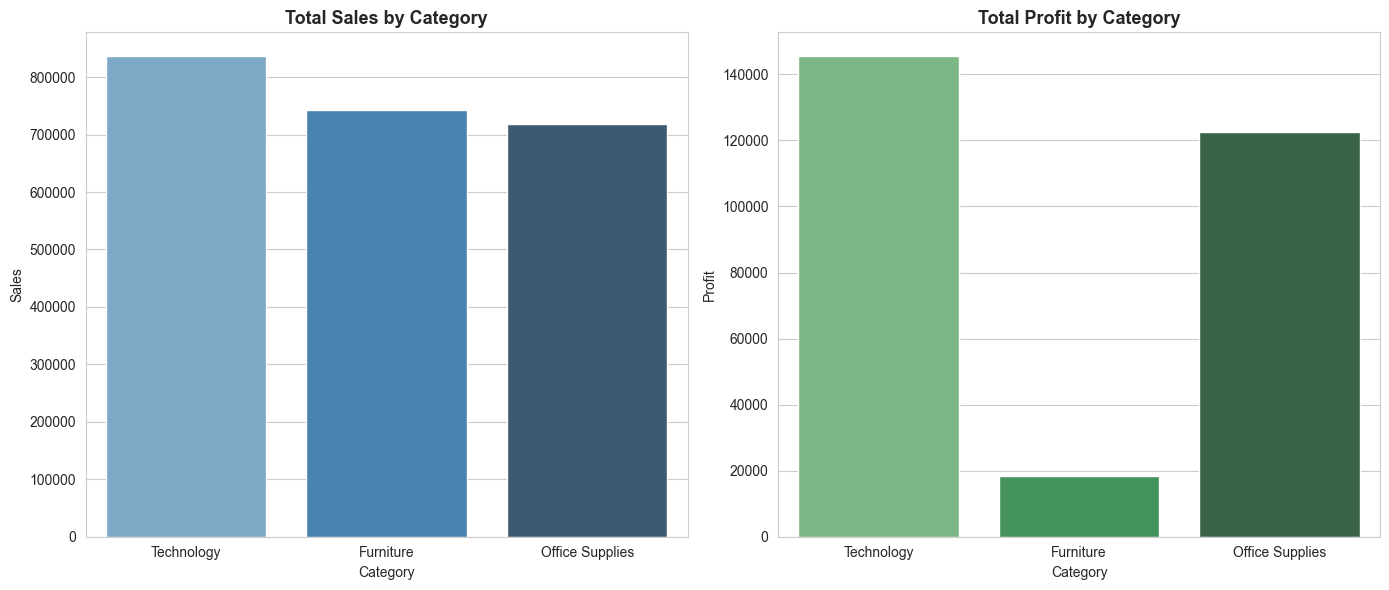

In [17]:
# Category performance chart (save karo)
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=category_summary.index, y=category_summary['Sales'], hue=category_summary.index, palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
sns.barplot(x=category_summary.index, y=category_summary['Profit'], hue=category_summary.index, palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
plt.tight_layout()

plt.savefig('../images/category_sales_profit.png', dpi=150, bbox_inches='tight')
plt.show()

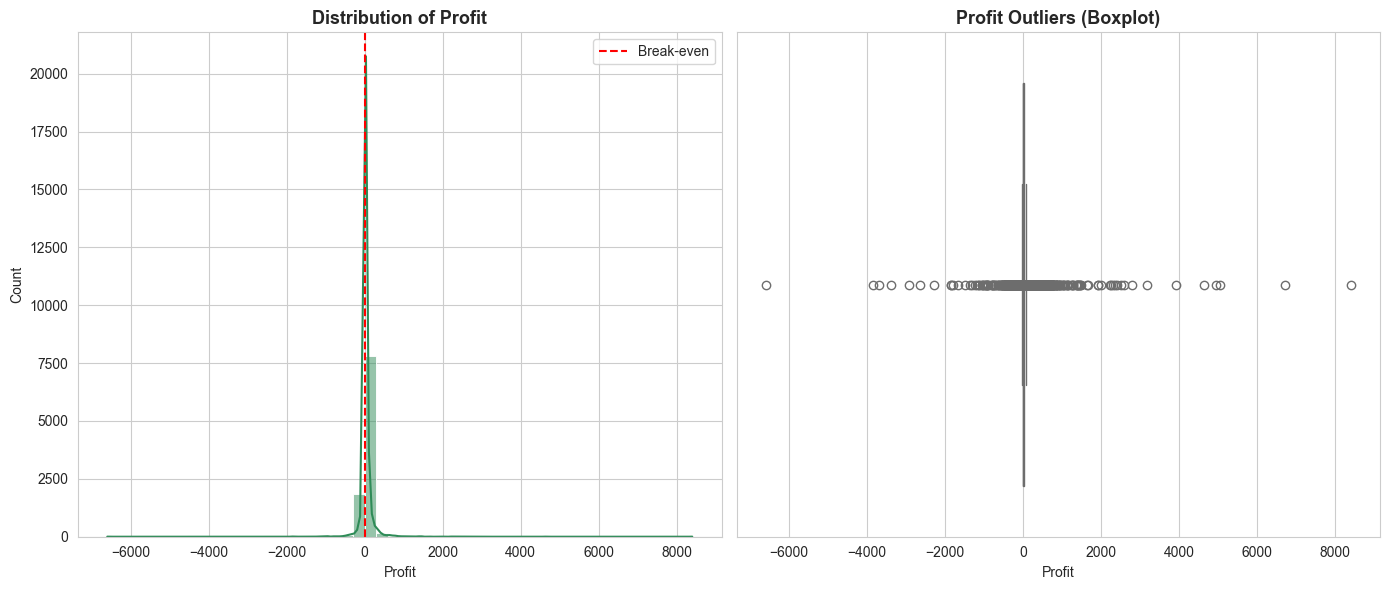

In [18]:
# Profit distribution chart (save karo)
fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.histplot(df['Profit'], bins=50, kde=True, color='seagreen', ax=axes[0])
axes[0].set_title('Distribution of Profit', fontsize=13, fontweight='bold')
axes[0].axvline(0, color='red', linestyle='--', label='Break-even')
axes[0].legend()
sns.boxplot(x=df['Profit'], color='salmon', ax=axes[1])
axes[1].set_title('Profit Outliers (Boxplot)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/profit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

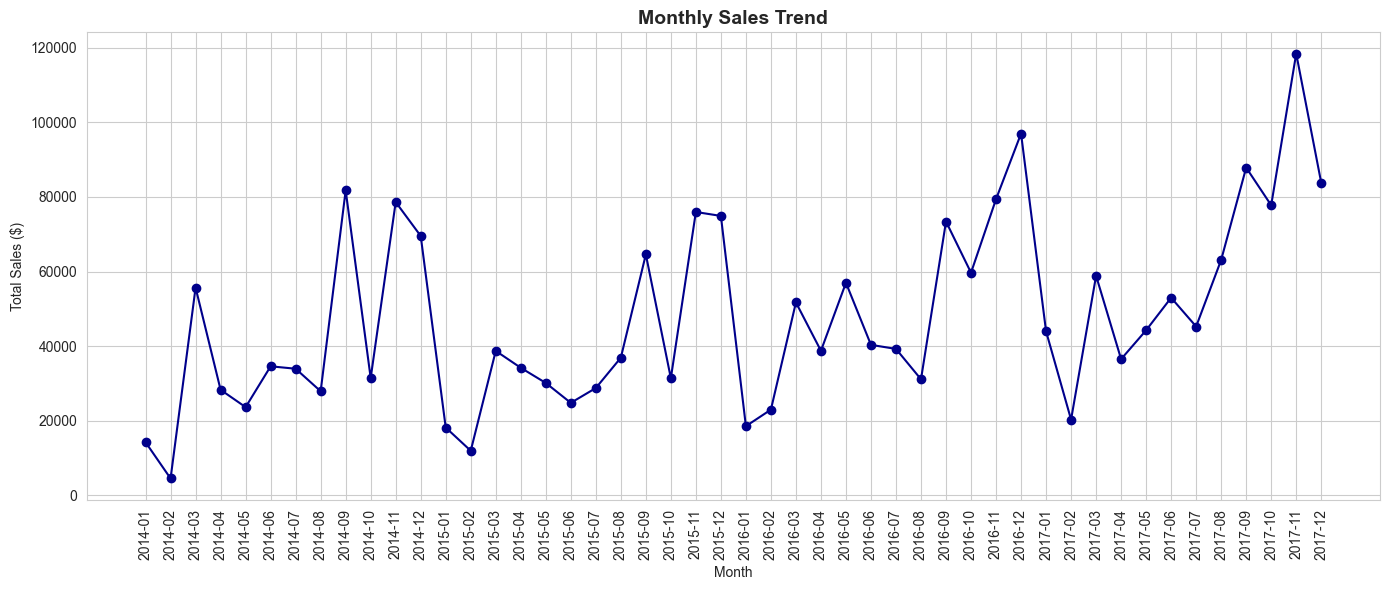

In [19]:
# Monthly sales trend (save karo)
monthly_sales = df.groupby('Order Month')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
plt.plot(monthly_sales['Order Month'], monthly_sales['Sales'], marker='o', color='darkblue')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()